## Importing Required Libraries
This cell imports essential Python libraries used for data analysis, visualization, and numerical computations.

In [23]:
# Import libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Lets load the dataset


## Mounting Google Drive
This step connects Google Colab with Google Drive so datasets and files can be accessed directly from your drive.

## Loading the California Housing Dataset
The California Housing dataset is imported from scikit-learn for practicing Linear Regression.

In [24]:
# Fetch California housing dataset from sklearn
from sklearn.datasets import fetch_california_housing
housing_df = fetch_california_housing()

In [25]:
housing_df.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

Lets check the description of the dataset

In [26]:
print(housing_df.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [27]:
print(housing_df.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [28]:
print(housing_df.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [29]:
print(housing_df.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Preparing the Dataset
In this section, the dataset is converted into a Pandas DataFrame for easier analysis and preprocessing.

Preparing the Dataset

In [30]:
# Convert dataset into a Pandas DataFrame
dataset=pd.DataFrame(housing_df.data,columns=housing_df.feature_names)

In [31]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [32]:
dataset['Price']=housing_df.target

In [33]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [34]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Statistical Summary of Dataset
This section provides descriptive statistics such as mean, standard deviation, minimum, and maximum values.

Summerizing the stats of the data

In [35]:
# Generate statistical summary of the dataset
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Checking Missing Values
Before training the model, it is important to check if the dataset contains any null or missing values.

Check the missing values *important

In [36]:
# Check for null values in the dataset
dataset.isnull()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
20635,False,False,False,False,False,False,False,False,False
20636,False,False,False,False,False,False,False,False,False
20637,False,False,False,False,False,False,False,False,False
20638,False,False,False,False,False,False,False,False,False


Additional added


In [37]:
Q1 = dataset.quantile(0.25)
Q3 = dataset.quantile(0.75)
IQR = Q3 - Q1

df_clean = dataset[~((dataset < (Q1 - 1.5 * IQR)) | (dataset > (Q3 + 1.5 * IQR))).any(axis=1)]
dataset = df_clean

In [38]:
# Check for null values in the dataset
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

Exploratory Data Analysis
1. Correlation


In [39]:
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.181014,0.698658,-0.256522,-0.002466,-0.031503,-0.078629,-0.009936,0.632971
HouseAge,-0.181014,1.000000,-0.209684,-0.071658,-0.272499,-0.005069,0.004834,-0.088993,0.087911
AveRooms,0.698658,-0.209684,1.000000,-0.001579,-0.067882,0.057669,0.131869,-0.092256,0.260237
AveBedrms,-0.256522,-0.071658,-0.001579,1.000000,0.082117,-0.085343,0.034775,-0.004277,-0.099079
Population,-0.002466,-0.272499,-0.067882,0.082117,1.000000,0.209546,-0.113037,0.104769,-0.005995
AveOccup,-0.031503,-0.005069,0.057669,-0.085343,0.209546,1.000000,-0.166071,0.186429,-0.275504
Latitude,-0.078629,0.004834,0.131869,0.034775,-0.113037,-0.166071,1.000000,-0.933286,-0.150479
Longitude,-0.009936,-0.088993,-0.092256,-0.004277,0.104769,0.186429,-0.933286,1.000000,-0.043103
Price,0.632971,0.087911,0.260237,-0.099079,-0.005995,-0.275504,-0.150479,-0.043103,1.000000


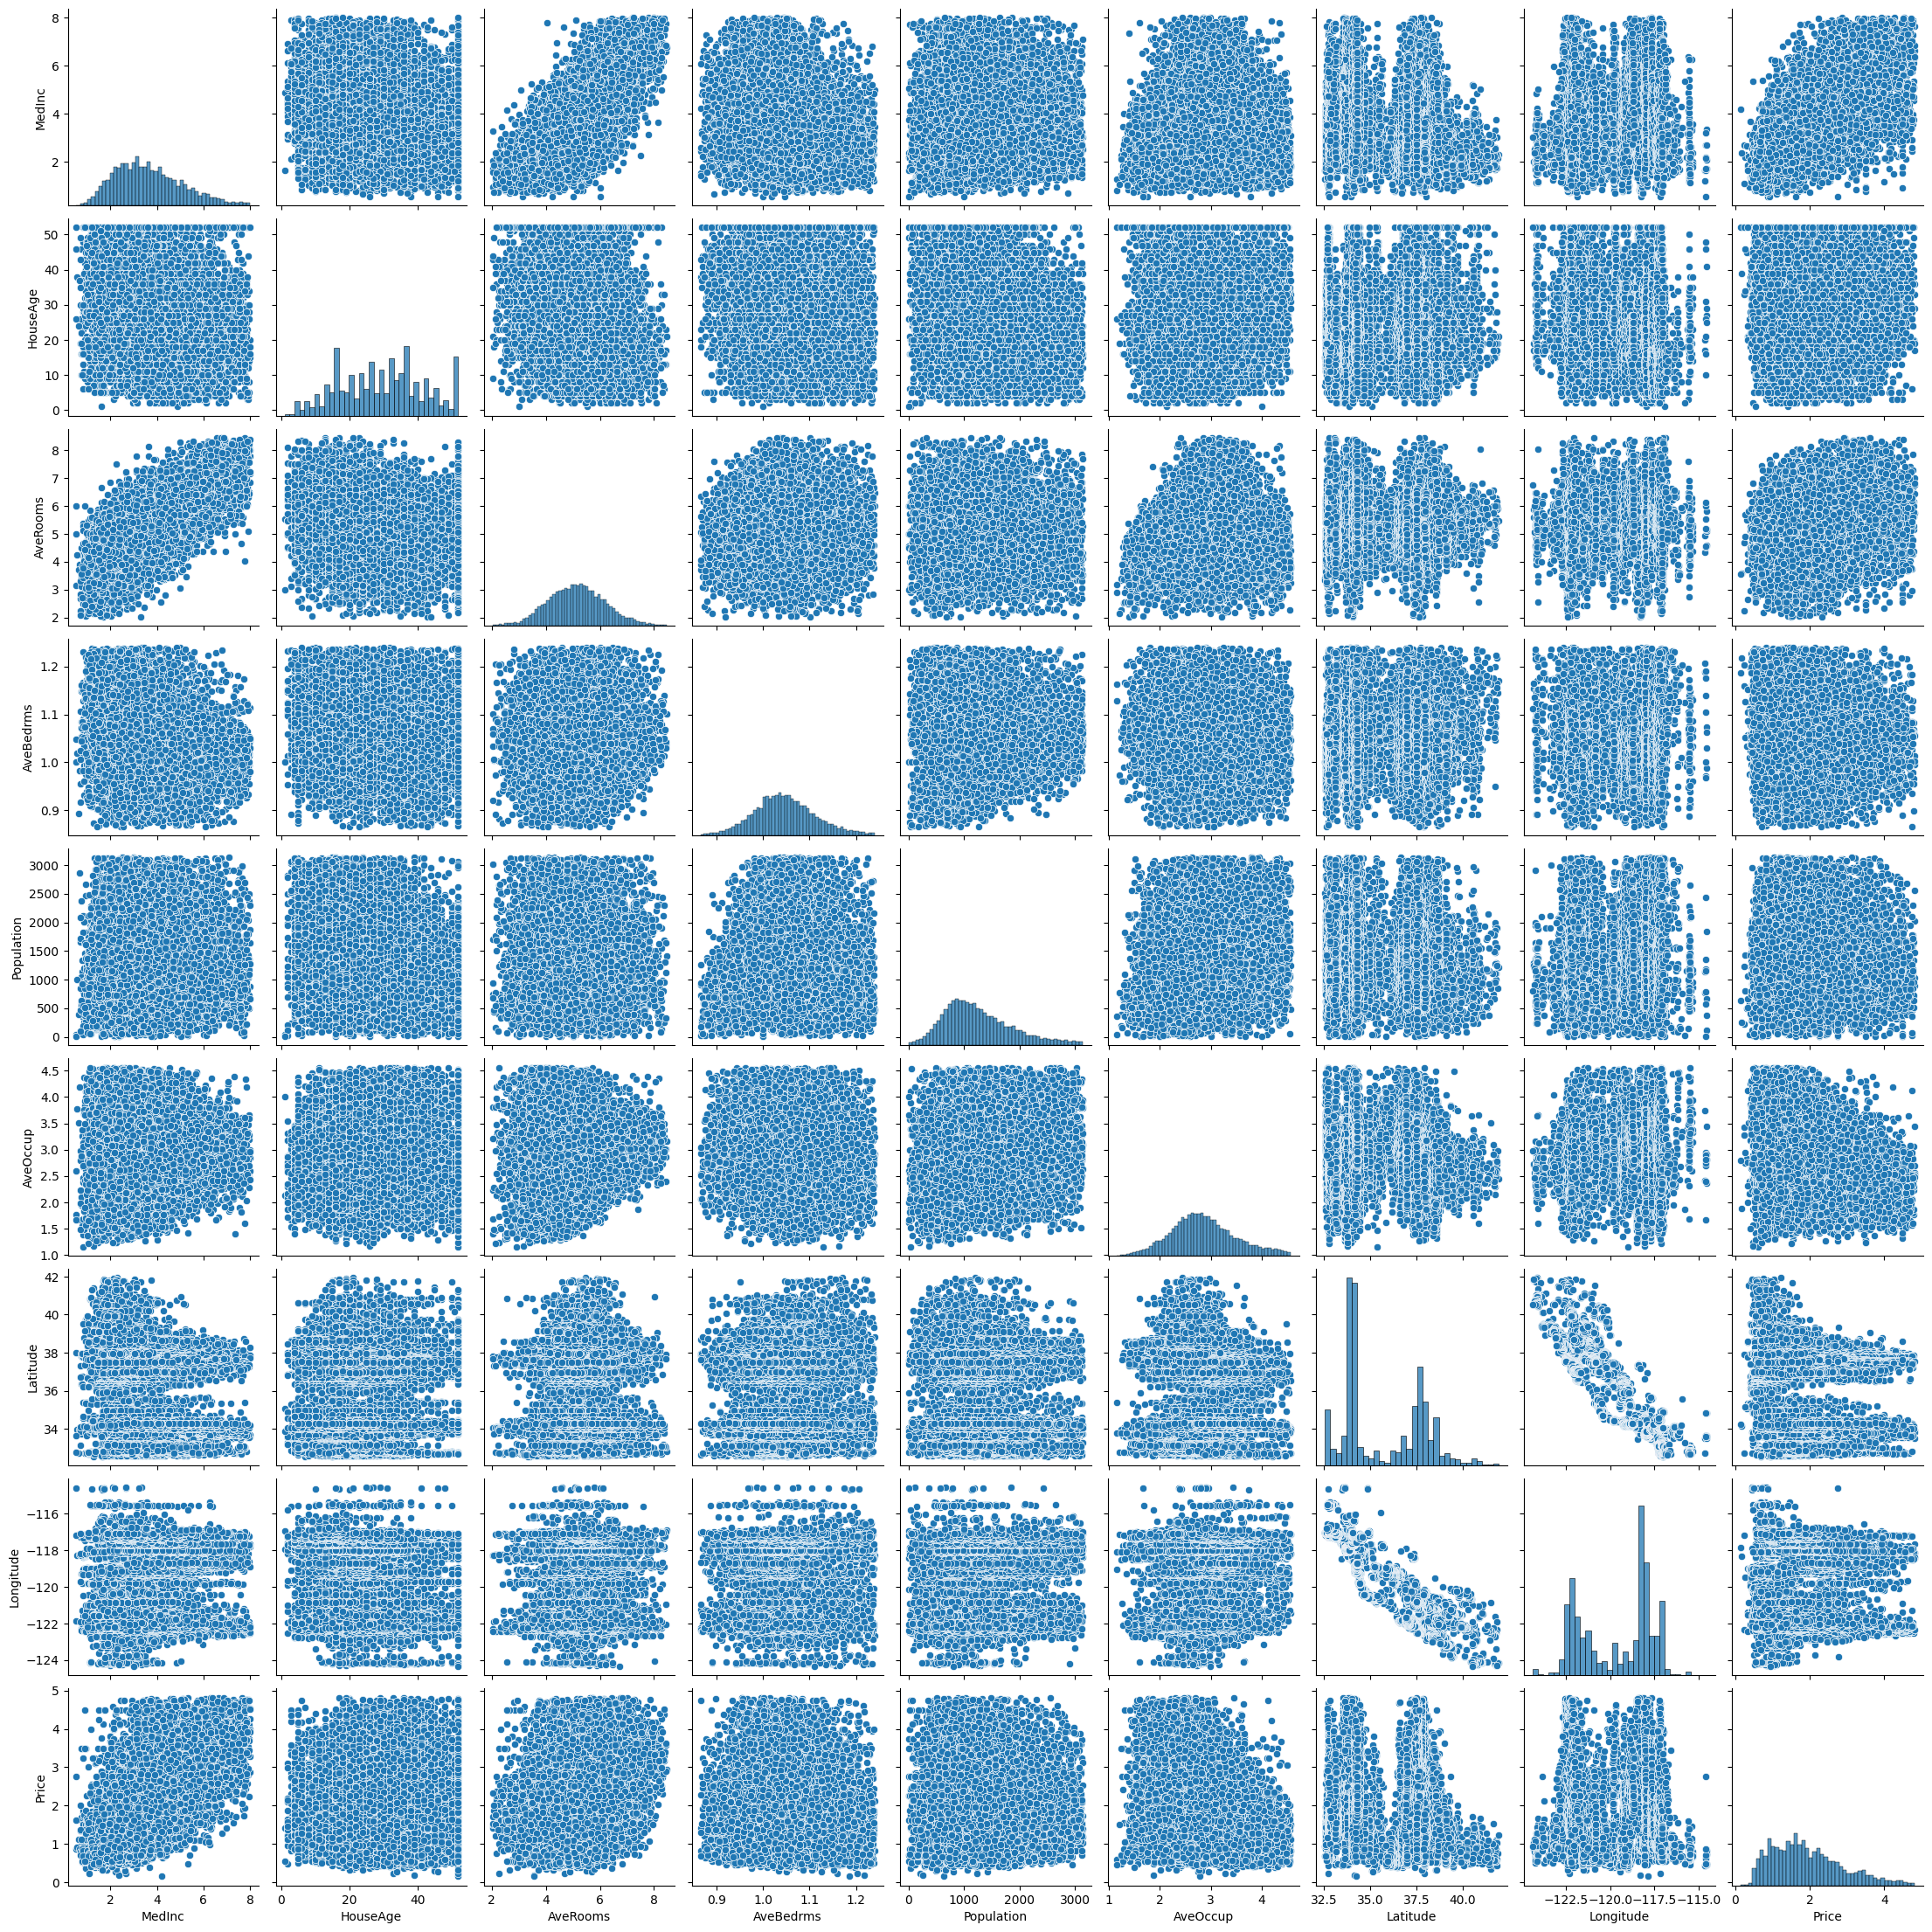

In [40]:
import seaborn as sns
sns.pairplot(dataset)

Analysis the correlation

Text(0, 0.5, 'Price')

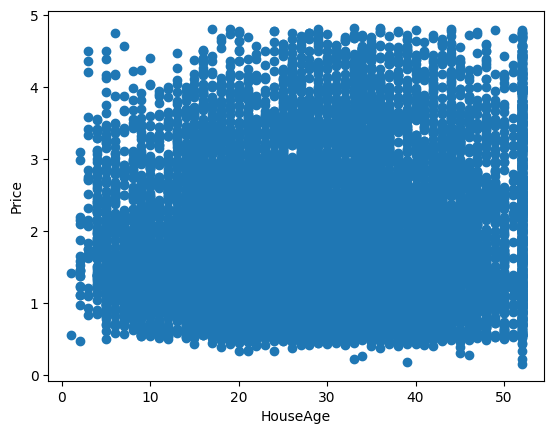

In [41]:
plt.scatter(dataset['HouseAge'],dataset['Price'])
plt.xlabel('HouseAge')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

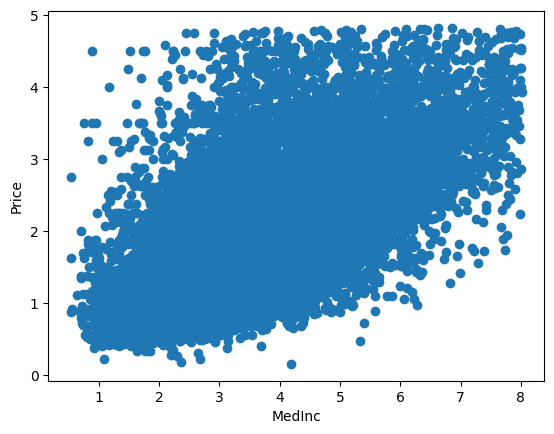

In [42]:
plt.scatter(dataset['MedInc'],dataset['Price'])
plt.xlabel('MedInc')
plt.ylabel('Price')

<Axes: xlabel='MedInc', ylabel='Price'>

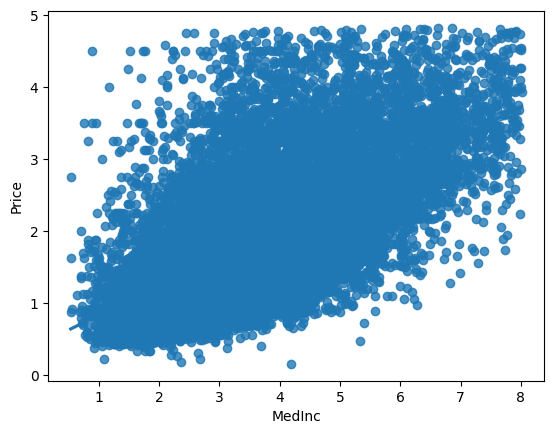

In [43]:
import seaborn as sns
sns.regplot(x='MedInc',y='Price',data=dataset)

<Axes: xlabel='AveOccup', ylabel='Price'>

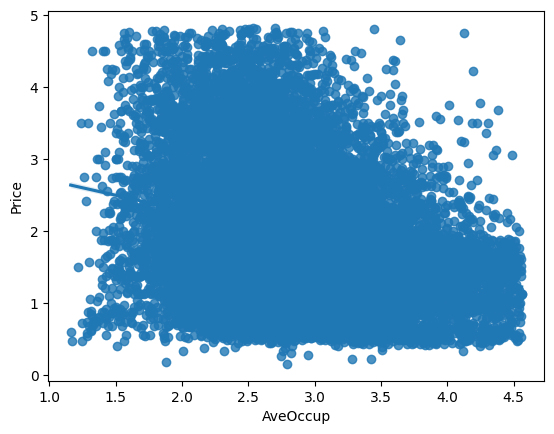

In [44]:
sns.regplot(x='AveOccup',y='Price',data=dataset)

Independent and Dependent features *divide dataset

In [45]:
dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
...,...,...,...,...,...,...,...,...,...
20634,3.7125,28.0,6.779070,1.148256,1041.0,3.026163,39.27,-121.56,1.168
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [46]:
x=dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]

In [47]:
x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25


In [48]:
y.head()

2    3.521
3    3.413
4    3.422
5    2.697
6    2.992
Name: Price, dtype: float64

Train Test split

In [49]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [50]:
x_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
15635,0.8836,30.0,2.662281,1.078947,1648.0,2.409357,37.80,-122.41
8498,2.7428,33.0,4.049242,1.073864,1072.0,2.030303,33.89,-118.29
10866,5.4836,18.0,5.271605,0.920988,1464.0,3.614815,33.70,-117.88
17364,3.1078,33.0,5.327074,1.112676,1579.0,2.471049,34.95,-120.42
1531,6.7192,30.0,7.130435,1.021739,847.0,2.630435,37.87,-122.05
...,...,...,...,...,...,...,...,...
17087,3.2708,43.0,4.188571,0.925714,497.0,2.840000,37.47,-122.21
6786,3.1080,27.0,4.365488,1.085745,2411.0,2.584137,34.10,-118.14
966,6.2918,22.0,7.746939,0.975510,734.0,2.995918,37.68,-121.89
19993,2.2500,33.0,4.924433,1.002519,1412.0,3.556675,36.20,-119.36


In [51]:
x_test.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
107,3.1691,52.0,4.165877,1.090047,686.0,1.625592,37.81,-122.25
4989,1.9792,47.0,4.816770,1.124224,1329.0,4.127329,34.00,-118.31
8000,4.6019,36.0,5.235732,1.032258,1128.0,2.799007,33.85,-118.13
8624,5.0602,34.0,5.960912,1.026059,822.0,2.677524,33.88,-118.38
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25


Standardize the dataset

In [52]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [53]:
x_train=scaler.fit_transform(x_train)

In [54]:
x_test=scaler.transform(x_test)

In [55]:
x_train

array([[-1.92772968,  0.05249225, -2.4014246 , ..., -0.72431609,
         0.99202614, -1.39000121],
       [-0.64230107,  0.29739412, -1.06991643, ..., -1.33237078,
        -0.83459156,  0.67201635],
       [ 1.25265522, -0.92711522,  0.10357355, ...,  1.20940586,
        -0.92335303,  0.87721712],
       ...,
       [ 1.81143502, -0.6005794 ,  2.47993851, ...,  0.21661013,
         0.93596626, -1.12974657],
       [-0.98301709,  0.29739412, -0.22971751, ...,  1.11614163,
         0.2445611 ,  0.13649237],
       [ 0.36048812,  1.84843927, -1.53106446, ..., -0.11192911,
        -0.67108358,  0.88722692]], shape=(11418, 8))

In [56]:
x_test

array([[-0.34756236,  1.84843927, -0.95794536, ..., -1.98158273,
         0.99669779, -1.30992286],
       [-1.17024497,  1.44026949, -0.33307599, ...,  2.03154999,
        -0.78320334,  0.66200655],
       [ 0.6430584 ,  0.54229598,  0.06913489, ..., -0.0992623 ,
        -0.85327818,  0.7520947 ],
       ...,
       [-0.40688345,  0.95046576, -0.74795236, ...,  1.80673043,
        -0.80656162,  0.72206531],
       [ 0.91829997, -0.76384731,  1.24954813, ..., -0.03874256,
         1.1461908 , -0.82945275],
       [-0.45534975,  1.19536763, -0.24773981, ...,  1.34302803,
        -0.81590493,  0.63698207]], shape=(4894, 8))

In [79]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))

Model Traning

In [57]:
from sklearn.linear_model import LinearRegression


In [58]:
regression=LinearRegression()

In [59]:
regression.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Print the Coefficients and the intercept

In [60]:
print(regression.coef_)

[ 0.65004888  0.12938006 -0.13086524  0.08430412  0.04886151 -0.22914947
 -0.85129384 -0.79414206]


In [61]:
print(regression.intercept_)

1.936155630583294


On which parameters the model has been trained

In [62]:
regression.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

Prediction with test data

In [63]:
reg_pred = regression.predict(x_test)

In [64]:
reg_pred

array([2.72892938, 1.18266208, 2.53674801, ..., 1.51728279, 1.97380684,
       1.69903091], shape=(4894,))

Assumptions
 - Plot a scatter plot for the prediction

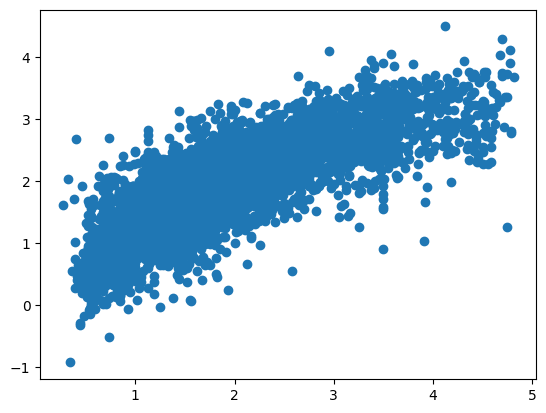

In [65]:
plt.scatter(y_test,reg_pred)

residual

In [66]:
residuals=y_test-reg_pred

In [67]:
residuals

107     -0.134929
4989    -0.018662
8000    -0.452748
8624     1.806148
5       -0.138002
           ...   
16689   -0.483744
10404   -0.162977
7438     0.130717
16457   -0.425807
8439     0.325969
Name: Price, Length: 4894, dtype: float64

Ploting this residuals

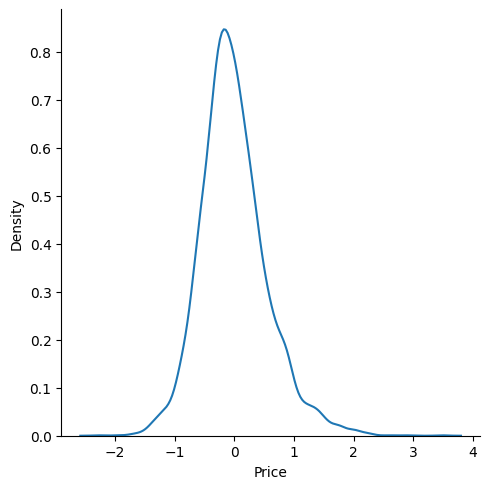

In [68]:
sns.displot(residuals,kind='kde')

Scatter plot with respect to predection and residuals
- Uniform Disturbution

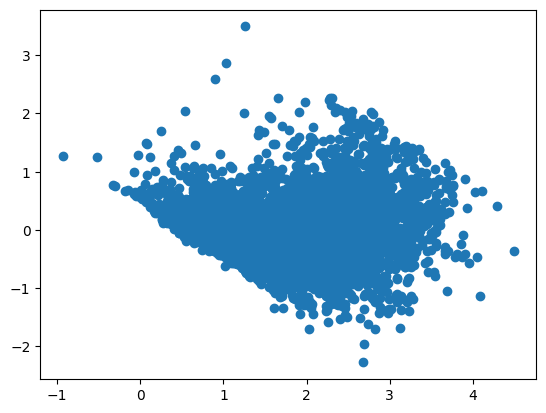

In [69]:
plt.scatter(reg_pred,residuals)

In [70]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test,reg_pred))
print(mean_squared_error(y_test,reg_pred))
print(np.sqrt(mean_squared_error(y_test,reg_pred)))


0.42361889744557485
0.3102000375145814
0.5569560463039982


#R sq. and adjusted R sq.

- R sq. Formula  -  **R^2 = 1 - SSR/SST**\
\
R^2 = coefficent of determination\
SSR = sum of sq. of residuals\
SST = total sum of sq.

- Adjusted R sq. - **R2 = 1-[(1-R2)*(n-1)/(n-k-1)]**\
\
R2 = The R2 of the model\
n = The number of observations\
k = The number of predictor variables

In [71]:
from sklearn.metrics import r2_score
score=r2_score(y_test,reg_pred)
print(score)

0.64368216739238


New Data Prediction

In [72]:
housing_df.data[0].reshape(1,-1).shape

(1, 8)

scaler transformation of new data

In [73]:
scaler.transform(housing_df.data[0].reshape(1,-1))

d:\ProjectMaterail\housepricing\housepricing\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 3.21730342,  0.95046576,  1.74762548, -0.35377335, -1.51818048,
        -0.48979289,  1.02939939, -1.29991306]])

In [74]:
regression.predict(scaler.transform(housing_df.data[0].reshape(1,-1)))

d:\ProjectMaterail\housepricing\housepricing\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4.08605294])

Pickling The Model file for Deployment

In [75]:
import pickle

In [76]:
pickle.dump(regression,open('regmodel.pkl','wb'))

In [77]:
pickled_model=pickle.load(open('regmodel.pkl','rb'))

Prediction

In [78]:
pickled_model.predict(scaler.transform(housing_df.data[0].reshape(1,-1)))

d:\ProjectMaterail\housepricing\housepricing\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4.08605294])